Install

In [1]:
# ============================================================
# CELL 1 — INSTALL & FIX PYTORCH COMPATIBILITY
# Training YOLOv8n Fine-tuning | Tugas 2 Visi Komputer
# Kelompok: Silvani, Cindy, Gloria | Mikroskil 2026
# ============================================================

# Upgrade ultralytics ke versi terbaru
!pip install -U ultralytics -q

import torch
import functools

print(f"PyTorch    : {torch.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")

# ── Fix PyTorch >= 2.6 compatibility ─────────────────────────
# PyTorch 2.6 mengubah default weights_only=True di torch.load
# yang menyebabkan error saat load model Ultralytics.
# Patch: kembalikan default ke False seperti versi sebelumnya.

_original_load = torch.load

@functools.wraps(_original_load)
def patched_load(*args, **kwargs):
    if "weights_only" not in kwargs:
        kwargs["weights_only"] = False
    return _original_load(*args, **kwargs)

torch.load = patched_load
print("✅ torch.load patched — kompatibel dengan Ultralytics")

# Verifikasi
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")

_test = YOLO("yolov8n.pt")
print(f"✅ Model test dimuat: {list(_test.names.values())[:5]}...")
del _test

print("\n✅ CELL 1 SELESAI — lanjut Cell 2")

PyTorch    : 2.11.0+cu128
CUDA       : True
✅ torch.load patched — kompatibel dengan Ultralytics
Ultralytics: 8.4.83
✅ Model test dimuat: ['person', 'bicycle', 'car', 'motorcycle', 'airplane']...

✅ CELL 1 SELESAI — lanjut Cell 2


Mount Drive & Cek Dataset

In [2]:
# ============================================================
# CELL 2 — MOUNT GOOGLE DRIVE & SETUP PATH
#
# Struktur folder yang diharapkan di Google Drive:
#
# MyDrive/
#   traffic-detection/
#     dataset/
#       yolo_dataset/
#         images/
#           train/   ← gambar .jpg hasil merge_dataset.py
#           val/
#           test/
#         labels/
#           train/   ← file .txt label YOLO
#           val/
#           test/
#         data.yaml
# ============================================================

from google.colab import drive
import os
import yaml

drive.mount("/content/drive")

# ── Definisi path ─────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/traffic-detection"
DATASET_DIR  = f"{DRIVE_BASE}/dataset/yolo_dataset"
DATA_YAML    = f"{DATASET_DIR}/data.yaml"
MODELS_DIR   = f"{DRIVE_BASE}/models"
RESULTS_DIR  = f"{DRIVE_BASE}/results/training"

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Drive base  : {DRIVE_BASE}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"data.yaml   : {DATA_YAML}")

# ── Cek data.yaml ada ────────────────────────────────────────
if not os.path.exists(DATA_YAML):
    print(f"\n❌ data.yaml TIDAK DITEMUKAN!")
    print(f"   Pastikan folder yolo_dataset sudah diupload ke Drive")
    raise FileNotFoundError(f"Tidak ada: {DATA_YAML}")

# ── Fix path di data.yaml → path absolut Colab ───────────────
# data.yaml yang dibuat di Windows berisi path Windows (C:\...)
# Harus diganti ke path absolut Colab (/content/drive/...)

with open(DATA_YAML, "r") as f:
    isi_lama = yaml.safe_load(f)

print(f"\nPath lama di data.yaml: {isi_lama.get('path', 'tidak ada')}")

isi_baru = {
    "path":  os.path.abspath(DATASET_DIR),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    isi_lama.get("nc",    4),
    "names": isi_lama.get("names", ["motor", "mobil", "bus", "truk"])
}

with open(DATA_YAML, "w") as f:
    yaml.dump(isi_baru, f, default_flow_style=False, sort_keys=False)

print(f"Path baru  : {isi_baru['path']}")
print(f"Kelas      : {isi_baru['names']}")
print(f"Jumlah kelas: {isi_baru['nc']}")

# ── Verifikasi semua folder ───────────────────────────────────
print(f"\nVerifikasi folder dataset:")
semua_ok = True

for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATASET_DIR, "images", split)
    lbl_dir = os.path.join(DATASET_DIR, "labels", split)

    n_img = len([f for f in os.listdir(img_dir)
                 if f.endswith((".jpg",".jpeg",".png"))]) \
            if os.path.exists(img_dir) else 0
    n_lbl = len([f for f in os.listdir(lbl_dir)
                 if f.endswith(".txt")]) \
            if os.path.exists(lbl_dir) else 0

    ok = "✅" if n_img > 0 and n_lbl > 0 else "❌"
    print(f"  {ok} {split:5s}: {n_img:4d} gambar | {n_lbl:4d} label")

    if n_img == 0 or n_lbl == 0:
        semua_ok = False

if not semua_ok:
    print("\n❌ Ada folder yang kosong!")
    print("   Pastikan merge_dataset.py sudah dijalankan dan")
    print("   folder yolo_dataset sudah diupload lengkap ke Drive")
    raise RuntimeError("Dataset tidak lengkap")

print(f"\n✅ CELL 2 SELESAI — dataset siap, lanjut Cell 3")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive base  : /content/drive/MyDrive/traffic-detection
Dataset dir : /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset
data.yaml   : /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset/data.yaml

Path lama di data.yaml: /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset
Path baru  : /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset
Kelas      : ['motor', 'mobil', 'bus', 'truk']
Jumlah kelas: 4

Verifikasi folder dataset:
  ✅ train:  130 gambar |  130 label
  ✅ val  :   54 gambar |   54 label
  ✅ test :   32 gambar |   32 label

✅ CELL 2 SELESAI — dataset siap, lanjut Cell 3


Cek GPU

In [4]:
# ============================================================
# CELL 3 — CEK GPU
# Jika GPU tidak tersedia:
#   Runtime → Change runtime type → T4 GPU → Save
# ============================================================

import torch

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    nama_gpu = torch.cuda.get_device_name(0)
    vram     = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU      : {nama_gpu}")
    print(f"VRAM     : {vram:.1f} GB")
    DEVICE   = "0"
    print(f"\n✅ GPU siap — training akan cepat (~20-40 menit)")
else:
    DEVICE = "cpu"
    print(f"\n⚠️  GPU tidak tersedia!")
    print(f"   Ganti: Runtime → Change runtime type → T4 GPU")
    raise RuntimeError("GPU diperlukan untuk training yang efisien")

print(f"\n✅ CELL 3 SELESAI — lanjut Cell 4")

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB

✅ GPU siap — training akan cepat (~20-40 menit)

✅ CELL 3 SELESAI — lanjut Cell 4


Konfigurasi Hyperparameter

In [5]:
# ============================================================
# CELL 4 — KONFIGURASI HYPERPARAMETER
# Ubah nilai di sini sesuai kebutuhan
# ============================================================

# ── Model ────────────────────────────────────────────────────
BASE_MODEL   = "yolov8n.pt"   # nano: ringan, cocok dataset kecil
PROJECT_NAME = "runs/train"   # folder output di Colab
RUN_NAME     = "yolov8n-simpanguniland-v1"

# ── Training ─────────────────────────────────────────────────
EPOCHS       = 100    # max epoch (early stop bisa berhenti lebih awal)
BATCH        = 16     # turunkan ke 8 jika CUDA out of memory
IMGSZ        = 640    # ukuran input model
PATIENCE     = 20     # early stopping: berhenti jika 20 epoch tidak improve
SEED         = 42
WORKERS      = 2

# ── Learning Rate ────────────────────────────────────────────
LR0          = 0.01   # learning rate awal
LRF          = 0.01   # learning rate final factor
WARMUP_EPOCHS = 3.0   # epoch warmup (LR naik perlahan di awal)
WEIGHT_DECAY = 0.0005
MOMENTUM     = 0.937

# ── Augmentasi ───────────────────────────────────────────────
# Mosaic: gabungkan 4 gambar → variasi data lebih banyak
# Sangat berguna untuk dataset kecil seperti kita
MOSAIC       = 1.0
FLIPLR       = 0.5    # flip horizontal (relevan: kendaraan dari kiri/kanan)
FLIPUD       = 0.0    # flip vertikal (tidak relevan: CCTV fixed)
HSV_H        = 0.015  # variasi hue
HSV_S        = 0.7    # variasi saturasi
HSV_V        = 0.4    # variasi kecerahan (penting: siang vs sore)
DEGREES      = 0.0    # rotasi (tidak perlu: kamera fixed)
TRANSLATE    = 0.1
SCALE        = 0.5
CLOSE_MOSAIC = 10     # matikan mosaic 10 epoch terakhir

NAMA_KELAS   = ["motor", "mobil", "bus", "truk"]

print("✅ Konfigurasi:")
print(f"   Base model   : {BASE_MODEL}")
print(f"   Epochs       : {EPOCHS} (early stop patience: {PATIENCE})")
print(f"   Batch size   : {BATCH}")
print(f"   Image size   : {IMGSZ}×{IMGSZ}")
print(f"   Device       : GPU {DEVICE}")
print(f"   Optimizer    : AdamW")
print(f"   Mosaic aug   : {MOSAIC}")
print(f"   LR awal      : {LR0}")

print(f"\n✅ CELL 4 SELESAI — lanjut Cell 5")

✅ Konfigurasi:
   Base model   : yolov8n.pt
   Epochs       : 100 (early stop patience: 20)
   Batch size   : 16
   Image size   : 640×640
   Device       : GPU 0
   Optimizer    : AdamW
   Mosaic aug   : 1.0
   LR awal      : 0.01

✅ CELL 4 SELESAI — lanjut Cell 5


 Training

In [6]:
# ============================================================
# CELL 5 — TRAINING
#
# Proses transfer learning + fine-tuning:
#   1. Load yolov8n.pt (COCO pretrained, 80 kelas)
#   2. Ganti detection head → 4 kelas kita
#   3. Fine-tune seluruh network pada dataset Simpang Uniland
#   4. Tiap epoch: forward pass → loss → backpropagation
#   5. Simpan best.pt = epoch dengan val mAP@0.5 terbaik
#
# Loss yang dioptimalkan:
#   box_loss : akurasi lokasi bounding box
#   cls_loss : akurasi klasifikasi kelas kendaraan
#   dfl_loss : distribution focal loss
#
# Estimasi waktu T4 GPU:
#   100 gambar  → ~5-10 menit
#   500 gambar  → ~15-25 menit
#   1000 gambar → ~30-50 menit
# ============================================================

from ultralytics import YOLO
import time

print("="*60)
print("  MULAI TRAINING — YOLOv8n Fine-tuning")
print("  Transfer Learning dari COCO → Simpang Uniland Medan")
print(f"  Data    : {DATA_YAML}")
print(f"  Device  : GPU T4")
print("="*60)

# Load base model pretrained COCO
model = YOLO(BASE_MODEL)
print(f"\n✅ Base model dimuat: {BASE_MODEL}")
print(f"   Kelas awal COCO  : {len(model.names)} kelas")
print(f"   → Akan diganti ke {len(NAMA_KELAS)} kelas kita\n")

t0 = time.time()

results = model.train(
    # Dataset
    data          = DATA_YAML,

    # Training config
    epochs        = EPOCHS,
    batch         = BATCH,
    imgsz         = IMGSZ,
    device        = DEVICE,
    workers       = WORKERS,
    seed          = SEED,
    patience      = PATIENCE,

    # Learning rate
    lr0           = LR0,
    lrf           = LRF,
    warmup_epochs = WARMUP_EPOCHS,
    weight_decay  = WEIGHT_DECAY,
    momentum      = MOMENTUM,
    optimizer     = "AdamW",
    cos_lr        = True,

    # Augmentasi
    mosaic        = MOSAIC,
    fliplr        = FLIPLR,
    flipud        = FLIPUD,
    hsv_h         = HSV_H,
    hsv_s         = HSV_S,
    hsv_v         = HSV_V,
    degrees       = DEGREES,
    translate     = TRANSLATE,
    scale         = SCALE,
    close_mosaic  = CLOSE_MOSAIC,

    # Output
    project       = PROJECT_NAME,
    name          = RUN_NAME,
    exist_ok      = True,
    save          = True,
    save_period   = 10,   # simpan checkpoint tiap 10 epoch
    plots         = True, # auto-generate grafik
    verbose       = True,
    rect          = False,
)

durasi      = (time.time() - t0) / 60
map50_train = results.results_dict.get("metrics/mAP50(B)", 0)

print(f"\n{'='*60}")
print(f"  ✅ TRAINING SELESAI!")
print(f"  Durasi       : {durasi:.1f} menit")
print(f"  Best mAP@0.5 : {map50_train*100:.1f}%")
print(f"  Output       : {PROJECT_NAME}/{RUN_NAME}/")
print(f"{'='*60}")

# Simpan variabel untuk cell berikutnya, MEMPERBAIKI PATH
BEST_PT_COLAB = f"runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt"
LAST_PT_COLAB = f"runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/last.pt"

import os
print(f"\n  best.pt ada: {os.path.exists(BEST_PT_COLAB)}")
print(f"\n✅ CELL 5 SELESAI — lanjut Cell 6")

  MULAI TRAINING — YOLOv8n Fine-tuning
  Transfer Learning dari COCO → Simpang Uniland Medan
  Data    : /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset/data.yaml
  Device  : GPU T4

✅ Base model dimuat: yolov8n.pt
   Kelas awal COCO  : 80 kelas
   → Akan diganti ke 4 kelas kita

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/traffic-detection/dataset/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=Non

Simpan ke Drive

In [10]:
# ============================================================
# CELL 6 — SIMPAN HASIL KE GOOGLE DRIVE
# ============================================================

import shutil
import os

print("="*60)
print("  MENYIMPAN HASIL KE GOOGLE DRIVE")
print("="*60)

# ── Simpan best.pt ────────────────────────────────────────────
if os.path.exists(BEST_PT_COLAB):
    dst_best = f"{MODELS_DIR}/best.pt"
    shutil.copy2(BEST_PT_COLAB, dst_best)
    ukuran = os.path.getsize(dst_best) / 1e6
    print(f"  ✅ best.pt → {dst_best}")
    print(f"     Ukuran : {ukuran:.1f} MB")
else:
    print(f"  ❌ best.pt tidak ditemukan: {BEST_PT_COLAB}")

# ── Simpan last.pt (untuk resume jika Colab disconnect) ───────
if os.path.exists(LAST_PT_COLAB):
    shutil.copy2(LAST_PT_COLAB, f"{MODELS_DIR}/last.pt")
    print(f"  ✅ last.pt → {MODELS_DIR}/last.pt")

# ── Simpan seluruh hasil training ke Drive ────────────────────
training_output = f"{PROJECT_NAME}/{RUN_NAME}"
if os.path.exists(training_output):
    shutil.copytree(training_output, RESULTS_DIR, dirs_exist_ok=True)
    print(f"  ✅ Hasil training → {RESULTS_DIR}")

# ── List semua file yang tersimpan ───────────────────────────
print(f"\n  File di {RESULTS_DIR}:")
for root, dirs, files in os.walk(RESULTS_DIR):
    for fname in sorted(files):
        fpath  = os.path.join(root, fname)
        ukuran = os.path.getsize(fpath) / 1e3
        rel    = os.path.relpath(fpath, RESULTS_DIR)
        print(f"    {rel:45s} {ukuran:8.1f} KB")

print(f"\n✅ CELL 6 SELESAI — lanjut Cell 7")

  MENYIMPAN HASIL KE GOOGLE DRIVE
  ✅ best.pt → /content/drive/MyDrive/traffic-detection/models/best.pt
     Ukuran : 6.2 MB
  ✅ last.pt → /content/drive/MyDrive/traffic-detection/models/last.pt

  File di /content/drive/MyDrive/traffic-detection/results/training:
    metrics_final.json                                 0.5 KB
    perbandingan_t1_vs_t2.png                         63.1 KB

✅ CELL 6 SELESAI — lanjut Cell 7


Evaluasi & Grafik

  EVALUASI MODEL PADA TEST SET
✅ Model dimuat: runs/detect/runs/train/yolov8n-simpanguniland-v1/weights/best.pt
   Kelas: ['motor', 'mobil', 'bus', 'truk']
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.2±0.1 MB/s, size: 80.0 KB)
val: Scanning /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset/labels/test... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 3.3it/s 9.7s
val: New cache created: /content/drive/MyDrive/traffic-detection/dataset/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.6s
                   all         32        174      0.957      0.663      0.666      0.567
                 motor          9         23          1      0.738      0.735      0.602
                 mobil        

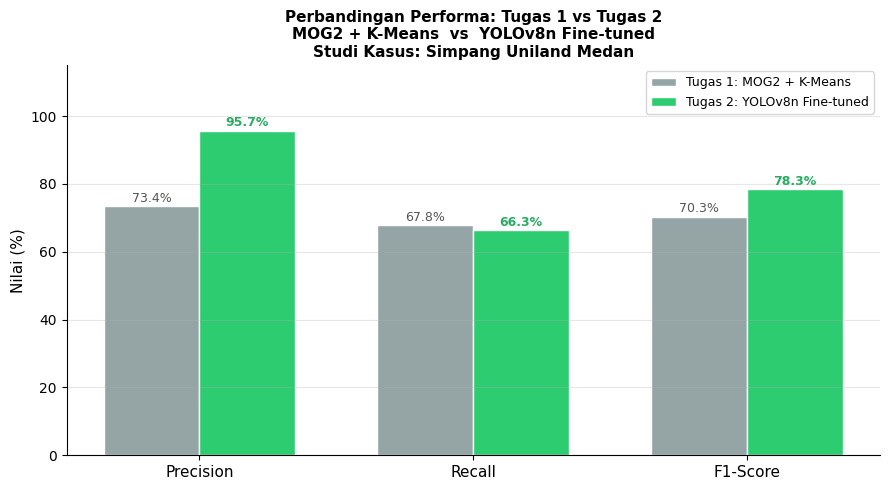

✅ Grafik perbandingan disimpan: /content/drive/MyDrive/traffic-detection/results/training/perbandingan_t1_vs_t2.png

✅ Metrik disimpan: /content/drive/MyDrive/traffic-detection/results/training/metrics_final.json

✅ CELL 8 SELESAI — lanjut Cell 9


In [8]:
# ============================================================
# CELL 8 — EVALUASI MODEL + GRAFIK TRAINING
# ============================================================

import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, Image as IPImage

print("="*60)
print("  EVALUASI MODEL PADA TEST SET")
print("="*60)

# ── Load model hasil fine-tuning ─────────────────────────────
model_eval = YOLO(BEST_PT_COLAB)
print(f"✅ Model dimuat: {BEST_PT_COLAB}")
print(f"   Kelas: {list(model_eval.names.values())}")

# ── Evaluasi pada test set ───────────────────────────────────
eval_results = model_eval.val(
    data     = DATA_YAML,
    split    = "test",
    conf     = 0.4,
    iou      = 0.5,
    imgsz    = IMGSZ,
    device   = DEVICE,
    verbose  = True,
    plots    = True,
    project  = PROJECT_NAME,
    name     = "evaluation",
    exist_ok = True,
)

# ── Ambil metrik ─────────────────────────────────────────────
mp      = float(eval_results.box.mp)
mr      = float(eval_results.box.mr)
map50   = float(eval_results.box.map50)
map5095 = float(eval_results.box.map)
f1      = 2 * mp * mr / (mp + mr) if (mp + mr) > 0 else 0.0

# AP per kelas
ap_per_kelas = {}
if hasattr(eval_results.box, "ap50") and hasattr(eval_results.box, "ap_class_index"):
    class_indices_muncul = eval_results.box.ap_class_index
    for idx_posisi, class_id_asli in enumerate(class_indices_muncul):
        if class_id_asli < len(NAMA_KELAS):
            nama_benar = NAMA_KELAS[int(class_id_asli)]
            ap_per_kelas[nama_benar] = float(eval_results.box.ap50[idx_posisi])

# Tampilkan kelas yang TIDAK muncul di test set secara eksplisit
kelas_tidak_ada_di_test = [
    nama for nama in NAMA_KELAS if nama not in ap_per_kelas
]
if kelas_tidak_ada_di_test:
    print(f"\n  ⚠️  Kelas tanpa instance di test set: {kelas_tidak_ada_di_test}")
    print(f"     AP tidak bisa dihitung untuk kelas ini (bukan berarti performanya buruk)")

# ── Tampilkan hasil ──────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  HASIL EVALUASI TEST SET")
print(f"{'='*60}")
print(f"  Precision (mean) : {mp*100:6.2f}%")
print(f"  Recall (mean)    : {mr*100:6.2f}%")
print(f"  F1-Score         : {f1*100:6.2f}%")
print(f"  mAP@0.5          : {map50*100:6.2f}%")
print(f"  mAP@0.5:0.95     : {map5095*100:6.2f}%")

if ap_per_kelas:
    print(f"\n  AP@0.5 per kelas:")
    for nama, ap in ap_per_kelas.items():
        bar = "█" * int(ap * 20)
        print(f"    {nama:8s}: {ap*100:5.1f}% {bar}")

# ── Perbandingan Tugas 1 vs Tugas 2 ─────────────────────────
print(f"\n{'─'*50}")
print(f"  PERBANDINGAN TUGAS 1 vs TUGAS 2")
print(f"{'─'*50}")
t1 = {"Precision": 0.734, "Recall": 0.678, "F1-Score": 0.703}
t2 = {"Precision": mp,    "Recall": mr,    "F1-Score": f1}
print(f"  {'Metrik':12s} | {'Tugas 1':9s} | {'Tugas 2':9s} | Δ")
print(f"  {'-'*48}")
for m in ["Precision", "Recall", "F1-Score"]:
    delta = t2[m] - t1[m]
    tanda = "+" if delta >= 0 else ""
    print(f"  {m:12s} | {t1[m]*100:7.1f}% | {t2[m]*100:7.1f}% | "
          f"{tanda}{delta*100:.1f}%")

# ── Grafik training loss ─────────────────────────────────────
csv_path = f"{PROJECT_NAME}/{RUN_NAME}/results.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(
        "Hasil Training YOLOv8n Fine-tuning\n"
        "Dataset: Simpang Uniland Medan | Tugas 2 Visi Komputer\n"
        "Kelompok: Silvani, Cindy, Gloria — Universitas Mikroskil 2026",
        fontsize=11, fontweight="bold"
    )

    plots = [
        ("train/box_loss",       "Train Box Loss",  axes[0,0], "#E74C3C"),
        ("val/box_loss",         "Val Box Loss",    axes[0,1], "#E67E22"),
        ("metrics/precision(B)", "Precision",       axes[0,2], "#3498DB"),
        ("metrics/recall(B)",    "Recall",          axes[1,0], "#2ECC71"),
        ("metrics/mAP50(B)",     "mAP@0.5",         axes[1,1], "#9B59B6"),
        ("metrics/mAP50-95(B)",  "mAP@0.5:0.95",   axes[1,2], "#795548"),
    ]

    for col, judul, ax, warna in plots:
        if col in df.columns:
            ax.plot(df["epoch"], df[col],
                    color=warna, linewidth=2)
            ax.set_title(judul, fontsize=10, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Tandai nilai terbaik
            if "loss" in col.lower():
                best_val = df[col].min()
                best_ep  = df.loc[df[col].idxmin(), "epoch"]
            else:
                best_val = df[col].max()
                best_ep  = df.loc[df[col].idxmax(), "epoch"]

            ax.axvline(x=best_ep, color="gray",
                       linestyle="--", alpha=0.5)
            ax.annotate(
                f"Best: {best_val:.3f}",
                xy=(best_ep, best_val),
                fontsize=8, color="#333",
                xytext=(5, 5),
                textcoords="offset points"
            )
        else:
            ax.text(0.5, 0.5, "Data\ntidak tersedia",
                    ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.set_title(judul, fontsize=10)

    plt.tight_layout()

    # Simpan grafik ke Drive
    grafik_path = f"{RESULTS_DIR}/training_detail.png"
    plt.savefig(grafik_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ Grafik training disimpan: {grafik_path}")

# ── Grafik perbandingan T1 vs T2 ─────────────────────────────
labels   = ["Precision", "Recall", "F1-Score"]
nilai_t1 = [0.734, 0.678, 0.703]
nilai_t2 = [mp, mr, f1]
x        = np.arange(len(labels))
lebar    = 0.35

fig2, ax2 = plt.subplots(figsize=(9, 5))

bar1 = ax2.bar(x - lebar/2, [v*100 for v in nilai_t1], lebar,
               label="Tugas 1: MOG2 + K-Means",
               color="#95A5A6", edgecolor="white")
bar2 = ax2.bar(x + lebar/2, [v*100 for v in nilai_t2], lebar,
               label="Tugas 2: YOLOv8n Fine-tuned",
               color="#2ECC71", edgecolor="white")

for bar in bar1:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5,
             f"{h:.1f}%", ha="center", va="bottom",
             fontsize=9, color="#555")
for bar in bar2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5,
             f"{h:.1f}%", ha="center", va="bottom",
             fontsize=9, color="#27AE60", fontweight="bold")

ax2.set_ylabel("Nilai (%)", fontsize=11)
ax2.set_title(
    "Perbandingan Performa: Tugas 1 vs Tugas 2\n"
    "MOG2 + K-Means  vs  YOLOv8n Fine-tuned\n"
    "Studi Kasus: Simpang Uniland Medan",
    fontsize=11, fontweight="bold"
)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, 115)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
plt.tight_layout()

perbandingan_path = f"{RESULTS_DIR}/perbandingan_t1_vs_t2.png"
plt.savefig(perbandingan_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Grafik perbandingan disimpan: {perbandingan_path}")

# ── Tampilkan confusion matrix ────────────────────────────────
conf_path = f"{PROJECT_NAME}/evaluation/confusion_matrix.png"
if os.path.exists(conf_path):
    shutil.copy2(conf_path, f"{RESULTS_DIR}/confusion_matrix.png")
    print(f"\n📊 Confusion Matrix:")
    display(IPImage(conf_path, width=500))

# ── Simpan metrik ke JSON ─────────────────────────────────────
metrik = {
    "model":               "YOLOv8n fine-tuned",
    "dataset":             "Simpang Uniland Medan",
    "precision":           round(mp, 4),
    "recall":              round(mr, 4),
    "f1_score":            round(f1, 4),
    "mAP50":               round(map50, 4),
    "mAP50_95":            round(map5095, 4),
    "ap_per_kelas":        {k: round(v,4) for k,v in ap_per_kelas.items()},
    "conf_threshold":      0.4,
    "iou_threshold":       0.5,
    "perbandingan_tugas1": {
        "precision_t1":    0.734,
        "recall_t1":       0.678,
        "f1_t1":           0.703,
        "precision_t2":    round(mp, 4),
        "recall_t2":       round(mr, 4),
        "f1_t2":           round(f1, 4),
        "delta_f1":        round(f1 - 0.703, 4),
    }
}

json_path = f"{RESULTS_DIR}/metrics_final.json"
with open(json_path, "w") as f:
    json.dump(metrik, f, indent=2, ensure_ascii=False)

print(f"\n✅ Metrik disimpan: {json_path}")
print(f"\n✅ CELL 8 SELESAI — lanjut Cell 9")

Quick Test Inference

In [11]:
# ============================================================
# CELL 9 — QUICK TEST INFERENCE
# Cek apakah best.pt mendeteksi kendaraan dengan benar
# ============================================================

import glob
import random
from ultralytics import YOLO
from IPython.display import display, Image as IPImage

model_test = YOLO(BEST_PT_COLAB)
print(f"✅ Model: {BEST_PT_COLAB}")
print(f"   Kelas: {list(model_test.names.values())}")

# Ambil gambar test
test_dir    = f"{DATASET_DIR}/images/test"
test_images = glob.glob(f"{test_dir}/*.jpg")

if not test_images:
    test_dir    = f"{DATASET_DIR}/images/val"
    test_images = glob.glob(f"{test_dir}/*.jpg")

sample = random.sample(test_images, min(6, len(test_images)))
print(f"\n🔍 Inference pada {len(sample)} gambar sample...\n")

hasil = model_test.predict(
    source   = sample,
    conf     = 0.4,
    iou      = 0.5,
    save     = True,
    project  = PROJECT_NAME,
    name     = "test_inference",
    exist_ok = True,
    verbose  = False,
)

# Tampilkan hasil
output_imgs = sorted(
    glob.glob(f"{PROJECT_NAME}/test_inference/*.jpg")
)[:6]

for img_path in output_imgs:
    display(IPImage(img_path, width=640))

# Simpan sample ke Drive
import os, shutil
sample_dir = f"{RESULTS_DIR}/inference_sample"
os.makedirs(sample_dir, exist_ok=True)
for img_path in output_imgs:
    shutil.copy2(img_path, sample_dir)

print(f"\n✅ Sample inference disimpan: {sample_dir}")
print(f"\n{'='*60}")
print(f"  🎉 SEMUA CELL SELESAI!")
print(f"{'='*60}")
print(f"  File tersimpan di Google Drive:")
print(f"  📦 best.pt     → {MODELS_DIR}/best.pt")
print(f"  📊 Grafik      → {RESULTS_DIR}/training_detail.png")
print(f"  📊 Perbandingan→ {RESULTS_DIR}/perbandingan_t1_vs_t2.png")
print(f"  📊 Conf Matrix → {RESULTS_DIR}/confusion_matrix.png")
print(f"  📋 Metrik JSON → {RESULTS_DIR}/metrics_final.json")
print(f"{'='*60}")

✅ Model: runs/detect/runs/train/yolov8n-simpanguniland-v1/weights/best.pt
   Kelas: ['motor', 'mobil', 'bus', 'truk']

🔍 Inference pada 6 gambar sample...

Results saved to /content/runs/detect/runs/train/test_inference

✅ Sample inference disimpan: /content/drive/MyDrive/traffic-detection/results/training/inference_sample

  🎉 SEMUA CELL SELESAI!
  File tersimpan di Google Drive:
  📦 best.pt     → /content/drive/MyDrive/traffic-detection/models/best.pt
  📊 Grafik      → /content/drive/MyDrive/traffic-detection/results/training/training_detail.png
  📊 Perbandingan→ /content/drive/MyDrive/traffic-detection/results/training/perbandingan_t1_vs_t2.png
  📊 Conf Matrix → /content/drive/MyDrive/traffic-detection/results/training/confusion_matrix.png
  📋 Metrik JSON → /content/drive/MyDrive/traffic-detection/results/training/metrics_final.json
